In [1]:
import pandas as pd
import ast

In [2]:
dfc=pd.read_csv("SI tables/SI_table_17_v7_combined.tsv",sep='\t',index_col=0)


In [3]:
cdd=pd.read_csv("outputs/cdsearch.tsv",sep="\t",index_col=0)

In [4]:
cdd=cdd[cdd.Query.isin([x.replace(" ","") for x in dfc.index])]

In [5]:

from collections import defaultdict

## dict between cdd accession and query
all_cdd = defaultdict(set)
for index, row in cdd.iterrows():
    all_cdd[f"{row['Short name']} ({row.Accession})"].add(row.Query)
counts_all_cdd={}
redundant=set()
seen=set()
## filter out redundant cdd in which all hits are filled by another annotation
for x in all_cdd:
    for y in all_cdd:
        if x!=y and (x,y) not in seen and (y,x) not in seen:
            if len(all_cdd[x])<len(all_cdd[y]) and len(all_cdd[x]-all_cdd[y])==0:
                redundant.add(x)
            
            if len(all_cdd[y])<len(all_cdd[x]) and len(all_cdd[y]-all_cdd[x])==0:
                redundant.add(y)
            elif len(all_cdd[x]-all_cdd[y])==0:
                redundant.add(x)
            seen.add((x,y))
            seen.add((y,x))
    counts_all_cdd[x]=len(all_cdd[x])
counts_all_cdd={x:counts_all_cdd[x] for x in counts_all_cdd if x not in redundant}
sorted_dict_all = dict(sorted(counts_all_cdd.items(), key=lambda item: item[1]))
keep=[x for x in sorted_dict_all if sorted_dict_all[x]>1]


In [6]:
df_all=pd.DataFrame()
for k in keep:
    df_all.loc[k,'N_HGT']=len(set([x.split(";")[1] for x in all_cdd[k] if 'HGT' in x]))
    df_all.loc[k,'N_Meta']=len(set([x.split(";")[1] for x in all_cdd[k] if 'Meta' in x]))
    df_all.loc[k,'N_total']=len(set([x.split(";")[1] for x in all_cdd[k]]))

In [7]:
df_all.index = [
    'NanM (COG3055)' if x == 'NanM superfamily (cl34543)' else x
    for x in df_all.index
]
df_all.index = [
    'An_peroxidase (pfam03098)' if x ==  'An_peroxidase superfamily (cl38107)' else x
    for x in df_all.index
]
df_all.index = [
    'CypX (COG2124)' if x == 'CypX superfamily (cl43611)' else x
    for x in df_all.index
]
df_all.index = [
    'Lipoprotein_11 (pfam03260)' if x == 'Lipoprotein_11 superfamily (cl03965)' else x
    for x in df_all.index
]

In [8]:
df_all=df_all[df_all.N_total>1]

In [9]:
rename_dict={'CBM_14 (pfam01607)':'Chitin binding peritrophin-A (pfam01607)',
'P-loop_NTPase superfamily (cl38936)':'P-loop NTPase (cl38936)',
'ps-ssRNAv_RdRp-like superfamily (cl40470)':'RNA-dependent RNA polymerase (cl40470)',
'PKc_like superfamily (cl21453)': 'Protein kinase catalytic domain (cl21453)',
'beta-trefoil_Ricin-like superfamily (cl49609)':'Ricin B-type lectin domain (cl49609)',
'CLECT superfamily (cl02432)': 'C-type lectin (cl02432)',
'Ldl_recept_a (pfam00057)': 'LDL receptor class A (pfam00057)',
'NanM (COG3055)':'N-acetylneuraminic acid mutarotase (COG3055)',
'AdoMet_MTases superfamily (cl17173)': 'SAM-dependent methyltransferase (cl17173)',
'An_peroxidase (pfam03098)': 'Haem peroxidase (pfam03098)',
'Tudor_SF superfamily (cl02573)': 'Tudor domain superfamily (cl02573)',
'Tryp_SPc superfamily (cl21584)':'Trypsin-like serine protease (cl21584)',
'CypX (COG2124)':'Cytochrome P450 (COG2124)',
'Lipoprotein_11 (pfam03260)': 'Low molecular weight lipoprotein (pfam03260)',
'NUC superfamily (cl00089)': 'Non-specific endonuclease (cl00089)',
'Glyco_tranf_GTA_type superfamily (cl11394)':'Glycosyltransferase family A (cl11394)',
'GH18_chitinase-like superfamily (cl10447)': 'GH18 chitinase (cl10447)',
'SGNH_hydrolase superfamily (cl01053)':'SGNH hydrolase (cl01053)'}

In [10]:
for index, row in df_all.iterrows():
    df_all.loc[index,'name']=rename_dict[index]

In [11]:
df_all

,N_HGT,N_Meta,N_total,name
SGNH_hydrolase superfamily (cl01053),2.0,0.0,2.0,SGNH hydrolase (cl01053)
GH18_chitinase-like superfamily (cl10447),2.0,0.0,2.0,GH18 chitinase (cl10447)
Glyco_tranf_GTA_type superfamily (cl11394),1.0,1.0,2.0,Glycosyltransferase family A (cl11394)
NUC superfamily (cl00089),2.0,0.0,2.0,Non-specific endonuclease (cl00089)
Lipoprotein_11 (pfam03260),2.0,0.0,2.0,Low molecular weight lipoprotein (pfam03260)
CypX (COG2124),0.0,2.0,2.0,Cytochrome P450 (COG2124)
Tryp_SPc superfamily (cl21584),1.0,1.0,2.0,Trypsin-like serine protease (cl21584)
Tudor_SF superfamily (cl02573),0.0,2.0,2.0,Tudor domain superfamily (cl02573)
An_peroxidase (pfam03098),0.0,2.0,2.0,Haem peroxidase (pfam03098)
AdoMet_MTases superfamily (cl17173),0.0,2.0,2.0,SAM-dependent methyltransferase (cl17173)


In [16]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

import matplotlib.font_manager
from matplotlib.font_manager import FontProperties

import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
fpath = Path(mpl.get_data_path(), "/n/holylabs/LABS/extavour_lab/Users/rkapoor/envs/plot/fonts/arial.ttf")
from matplotlib.font_manager import FontProperties
from matplotlib import font_manager
plt.rcParams['figure.dpi'] = 300
font_path = "/n/holylabs/LABS/extavour_lab/Users/rkapoor/envs/plot/fonts/arial.ttf"
font_manager.fontManager.addfont("/n/holylabs/LABS/extavour_lab/Users/rkapoor/envs/plot/fonts/arial.ttf")
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['svg.fonttype']='none'

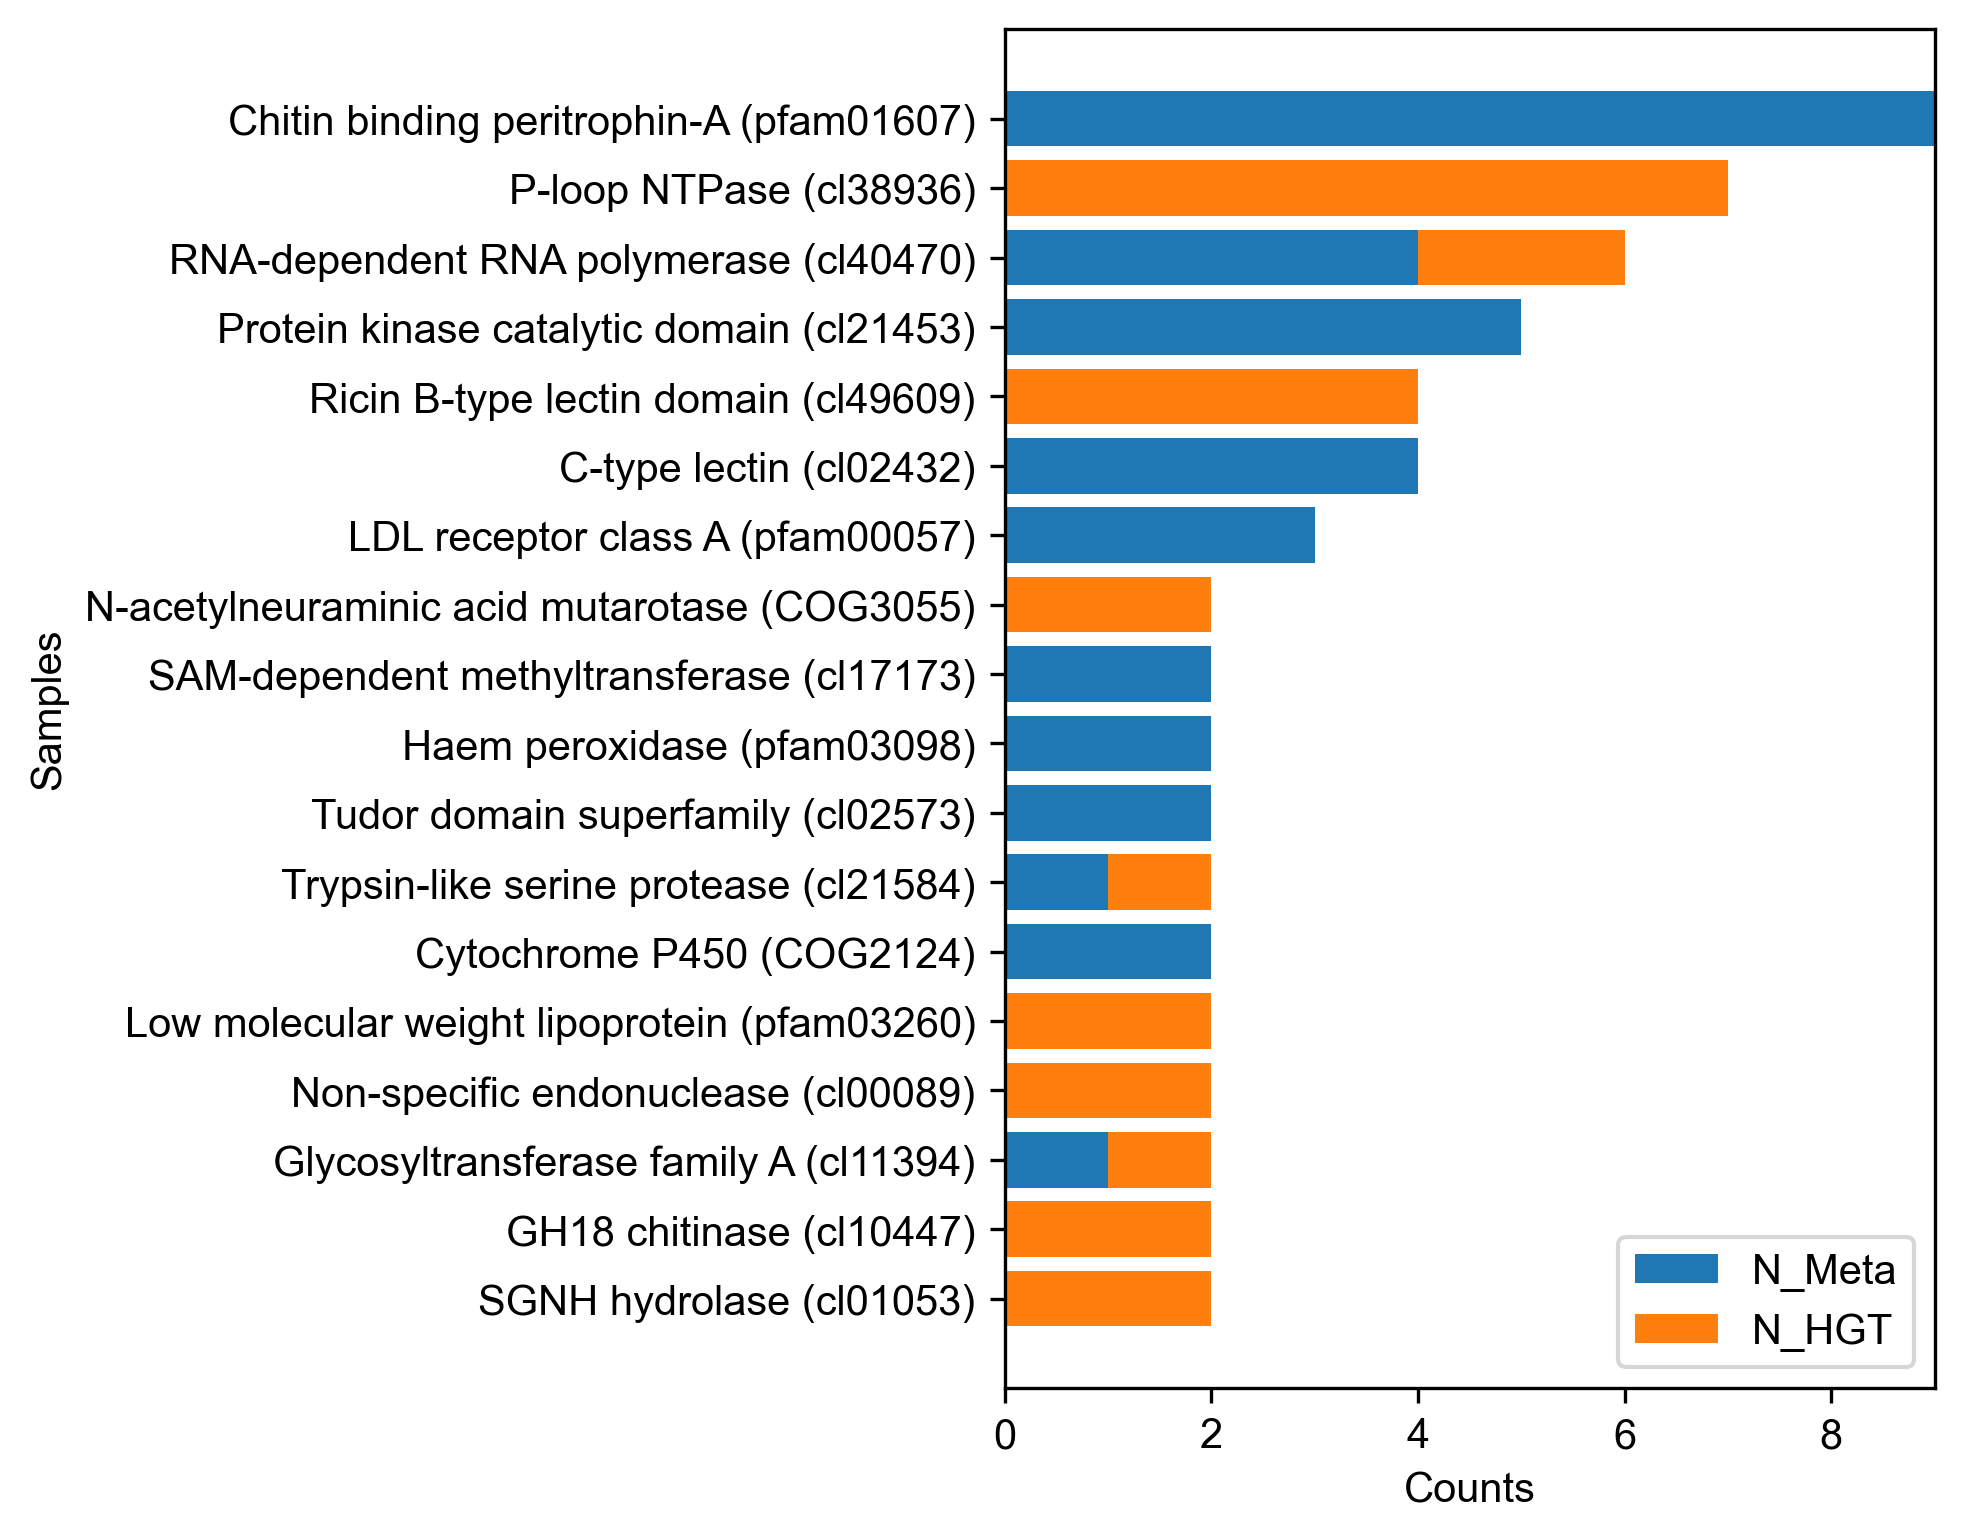

In [22]:

fig, ax = plt.subplots(figsize=(4, 6)) 
# first layer
ax.barh(df_all.index, df_all["N_Meta"], label="N_Meta")

# second layer stacked on top
ax.barh(df_all.index, df_all["N_HGT"], left=df_all["N_Meta"], label="N_HGT")

ax.set_xlabel("Counts")
ax.set_ylabel("Samples")  
ax.legend()

plt.savefig('figures/top_CDD_summary.svg',bbox_inches="tight",format='svg')